In [77]:
import pandas as pd
import datetime as dt

# 1. Load the dataset (Ensure the file path matches where you saved the CSV)
# If using Google Colab, you might need to upload the file first.
df = pd.read_csv('online_retail_II.csv')

print("Original Shape:", df.shape)

# 2. Basic Cleaning
# Drop rows where Customer ID is missing
df.dropna(subset=['Customer ID'], inplace=True)

# Remove cancellations (Invoice numbers starting with 'C')
df = df[~df['Invoice'].str.contains('C', na=False)]

# Remove rows with negative or zero Quantity/Price
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# 3. Data Transformation
# Convert InvoiceDate to datetime objects
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create a TotalPrice column (Quantity * Price)
df['Total_Price'] = df['Quantity'] * df['Price']

print("Cleaned Shape:", df.shape)
df.head()

Original Shape: (1067371, 8)
Cleaned Shape: (805549, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total_Price
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [78]:
# Set the analysis date to one day after the last transaction
today_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# Group by Customer ID to calculate R, F, M
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda date: (today_date - date.max()).days, # Recency
    'Invoice': lambda inv: inv.nunique(),                       # Frequency
    'Total_Price': lambda price: price.sum()                   # Monetary
})

# Rename columns for clarity
rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,5633.32
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [79]:
# Create scores from 1 to 5
# For Recency: Lower is better, so labels=[5, 4, 3, 2, 1]
rfm["recency_score"] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])

# For Frequency and Monetary: Higher is better, so labels=[1, 2, 3, 4, 5]
# Note: Frequency may have duplicate values, so we use 'rank(method="first")' 
# Using quantiles pd.qcut to divide in 5 groups
rfm["frequency_score"] = pd.qcut(rfm['Frequency'].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])
rfm["monetary_score"] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# Combine Recency and Frequency to get a 'Segment Score'
rfm['RF_Score'] = (rfm['recency_score'].astype(str) + rfm['frequency_score'].astype(str))

rfm.head()

,Recency,Frequency,Monetary,recency_score,frequency_score,monetary_score,RF_Score
Customer ID,,,,,,,
12346.0,326,12,77556.46,2,5,5,25
12347.0,2,8,5633.32,5,4,5,54
12348.0,75,5,2019.40,3,4,4,34
12349.0,19,4,4428.69,5,3,5,53
12350.0,310,1,334.40,2,1,2,21


In [80]:
seg_map = {
    r'[1-2][1-2]': 'hibernating',
    r'[1-2][3-4]': 'at_Risk',
    r'[1-2]5': 'cant_loose',
    r'3[1-2]': 'about_to_sleep',
    r'33': 'need_attention',
    r'[3-4][4-5]': 'loyal_customers',
    r'41': 'promising',
    r'51': 'new_customers',
    r'[4-5][2-3]': 'potential_loyalists',
    r'5[4-5]': 'champions'
}

rfm['Segment'] = rfm['RF_Score'].replace(seg_map, regex=True)
rfm.head()

,Recency,Frequency,Monetary,recency_score,frequency_score,monetary_score,RF_Score,Segment
Customer ID,,,,,,,,
12346.0,326,12,77556.46,2,5,5,25,cant_loose
12347.0,2,8,5633.32,5,4,5,54,champions
12348.0,75,5,2019.40,3,4,4,34,loyal_customers
12349.0,19,4,4428.69,5,3,5,53,potential_loyalists
12350.0,310,1,334.40,2,1,2,21,hibernating


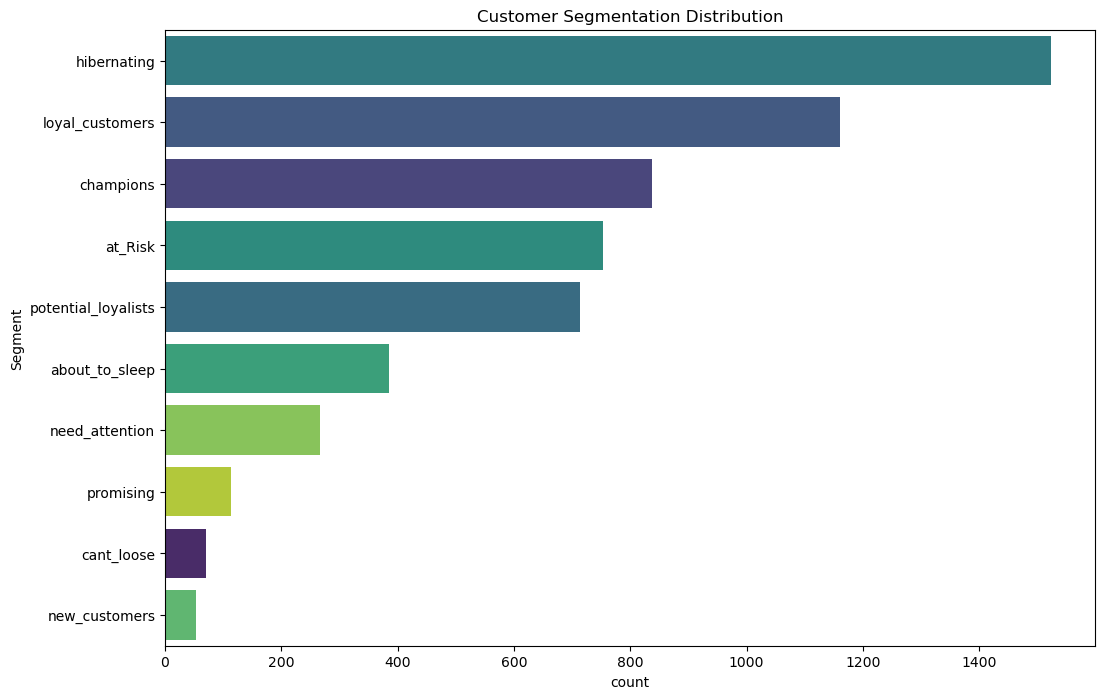

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.countplot(data=rfm, y='Segment', order=rfm['Segment'].value_counts().index, hue='Segment', legend=False, palette='viridis')
plt.title('Customer Segmentation Distribution')
plt.show()

In [84]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Create a binary target: 1 if Recency > 90 days (Churned), 0 otherwise (Active)
# You can adjust '90' based on your specific dataset's timeframe
rfm['Churn'] = rfm['Recency'].apply(lambda x: 1 if x > 90 else 0)

# Features (X) and Target (y)
X_fair = rfm[['Frequency', 'Monetary']] 
y = rfm['Churn']

# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X_fair, y, test_size=0.20, random_state=42)

In [85]:
# Initialize and train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.63      0.57      0.60       589
           1       0.60      0.66      0.63       587

    accuracy                           0.62      1176
   macro avg       0.62      0.62      0.61      1176
weighted avg       0.62      0.62      0.61      1176



In [86]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Total Model Accuracy: {accuracy * 100:.2f}%")

Total Model Accuracy: 61.56%


In [87]:
# Feature Engineering: Average Spend per Transaction
rfm['Avg_Spend'] = rfm['Monetary'] / rfm['Frequency']
# Calculate Lifetime
rfm['Customer_Lifetime'] = df.groupby('Customer ID')['InvoiceDate'].agg(lambda x: (x.max() - x.min()).days)

# Use Frequency - 1 for the interval (to represent the gaps between purchases)
# We add a small 1 to the denominator to avoid dividing by zero
rfm['Purchase_Interval'] = rfm['Customer_Lifetime'] / (rfm['Frequency'] - 1).replace(0, 1)

# New Feature Idea: Monetary per Day
rfm['Daily_Value'] = rfm['Monetary'] / (rfm['Customer_Lifetime'] + 1)

# Add these two new ones:
# rfm['Recency_Ratio'] = rfm['Recency'] / (rfm['Customer_Lifetime'] + 1)
rfm['Log_Monetary'] = np.log1p(rfm['Monetary'])

# To move segment and churn at last column
# Identify all columns except the ones we want at the end
cols = [c for c in rfm.columns if c not in ['Segment', 'Churn']]

# Reorder by adding the target columns to the end
rfm = rfm[cols + ['Segment', 'Churn']]

rfm.head()


,Recency,Frequency,Monetary,recency_score,frequency_score,monetary_score,RF_Score,Avg_Spend,Customer_Lifetime,Purchase_Interval,Daily_Value,Log_Monetary,Segment,Churn
Customer ID,,,,,,,,,,,,,,
12346.0,326,12,77556.46,2,5,5,25,6463.038333,400,36.363636,193.407631,11.258774,cant_loose,1
12347.0,2,8,5633.32,5,4,5,54,704.165000,402,57.428571,13.978462,8.636632,champions,0
12348.0,75,5,2019.40,3,4,4,34,403.880000,362,90.500000,5.563085,7.611051,loyal_customers,0
12349.0,19,4,4428.69,5,3,5,53,1107.172500,570,190.000000,7.756025,8.396085,potential_loyalists,0
12350.0,310,1,334.40,2,1,2,21,334.400000,0,0.000000,334.400000,5.815324,hibernating,1


In [89]:
# New Features
X_improved = rfm[['Frequency','Avg_Spend','Customer_Lifetime','Purchase_Interval','Daily_Value','Log_Monetary']]
y = rfm['Churn']
# Re-train
X_train, X_test, y_train, y_test = train_test_split(X_improved, y, test_size=0.20, random_state=42)
model.fit(X_train, y_train)

# Check new accuracy
print(f"New Accuracy: {model.score(X_test, y_test):.2%}")

New Accuracy: 68.45%


In [90]:
# import joblib

# # Save the model to a file
# joblib.dump(model, 'churn_model.pkl')

# # Save the scaler or any other objects if you used them (for now, just the model)
# print("Model saved as churn_model.pkl")

In [103]:
# from sklearn.model_selection import GridSearchCV

# # Define a "Grid" of parameters to try
# param_grid = {
#     'n_estimators': [100, 200],
#     'max_depth': [5, 6, 7, 8],
#     'min_samples_split': [10, 20, 50],
#     'min_samples_leaf': [10, 20, 50]
# }

# grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
# grid_search.fit(X_train, y_train)

# print(f"Best Parameters: {grid_search.best_params_}")
# print(f"Best Score: {grid_search.best_score_:.2%}")

# # Use this best model for your final app
# best_model = grid_search.best_estimator_

# # Best Parameters: {'max_depth': 8, 'min_samples_leaf': 10, 'min_samples_split': 50, 'n_estimators': 200}
# # Best Score: 73.16%

In [104]:
from sklearn.ensemble import RandomForestClassifier

# We are "pruning" the trees to stop them from memorizing
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,           # This is the "speed limit" - stops deep memorization
    min_samples_leaf=10,    # Each 'leaf' needs 50 customers to make a decision
    min_samples_split= 50,
    max_features='sqrt',    # Only looks at a few features at a time
    random_state=42
)

model.fit(X_train, y_train)

# final_model = grid_search.best_estimator_

# 2. Check the Final "Final" Accuracy on the TEST set
# test_acc = final_model.score(X_test, y_test)

# Now check the scores again
print(f"New Training Acc: {model.score(X_train, y_train):.2%}")
print(f"New Testing Acc: {model.score(X_test, y_test):.2%}")

New Training Acc: 76.56%
New Testing Acc: 73.30%


In [105]:
import joblib

# Save the model to a file
joblib.dump(model, 'churn_model.pkl')

# Save the scaler or any other objects if you used them (for now, just the model)
print("Model saved as churn_model.pkl")

Model saved as churn_model.pkl


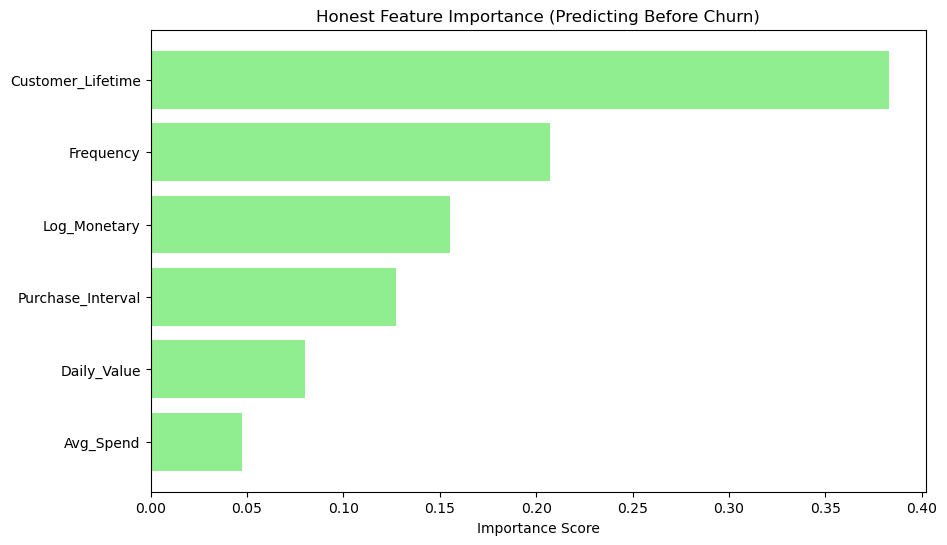

In [106]:
import pandas as pd
import matplotlib.pyplot as plt

# Check Honest Feature Importance
importances = model.feature_importances_
feature_names = X_improved.columns
feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plot it
plt.figure(figsize=(10, 6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='lightgreen')
plt.xlabel('Importance Score')
plt.title('Honest Feature Importance (Predicting Before Churn)')
plt.gca().invert_yaxis()
plt.show()

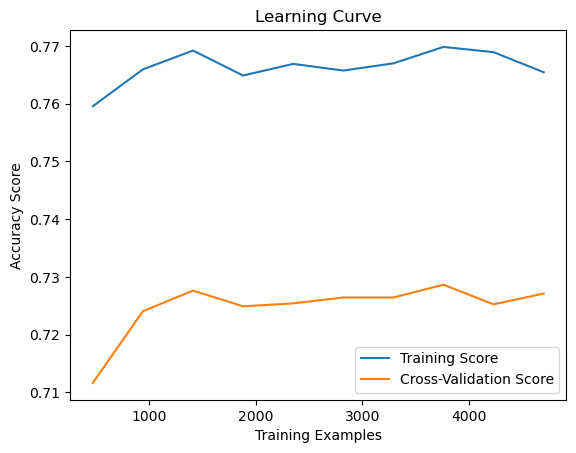

In [107]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# Calculate learning curve
train_sizes, train_scores, test_scores = learning_curve(
    model, X_improved, y, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10)
)

# Calculate mean and standard deviation
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# Plot the results
plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Cross-Validation Score")
plt.title("Learning Curve")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy Score")
plt.legend()
plt.show()